In [1]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Compute cosine similarity matrix between all gradient results
import torch.nn.functional as F

In [2]:
# def compute_cosine_similarity_matrix(results):
#     """Compute pairwise cosine similarity matrix for gradient results."""
#     n = len(results)
#     cosine_sim_matrix = torch.zeros(n, n)

#     # Compute cosine similarity for each pair (only upper triangle since it's symmetric)
#     for i in range(n):
#         for j in range(i, n):
#             grad_i = results[i].gradient
#             grad_j = results[j].gradient

#             # Compute cosine similarity
#             cos_sim = F.cosine_similarity(grad_i.unsqueeze(0),
#                                           grad_j.unsqueeze(0)).item()

#             # Fill both (i,j) and (j,i) since matrix is symmetric
#             cosine_sim_matrix[i, j] = cos_sim
#             cosine_sim_matrix[j, i] = cos_sim

#     return cosine_sim_matrix


def compute_success(df_data,
                    threshold_angle=0.1,
                    consecutive_steps=100,
                    starting_step=0,
                    column_name=None):
    """
    Compute whether the pole is upright (straight) for consecutive_steps time points.
    
    Args:
        df_data: DataFrame with 'observations' column containing state arrays
        threshold_angle: Maximum angle deviation from vertical (in radians) to consider "straight"
        consecutive_steps: Number of consecutive steps required for success
    
    Returns:
        df_data: DataFrame with added 'success' column
    """
    success = []

    for idx in range(len(df_data)):
        observations = np.array(df_data['observations'].iloc[idx])
        observations = observations[starting_step:]

        # Extract cos and sin of pole angle (dimensions 1 and 2)
        cos_angle = observations[:, 1]
        sin_angle = observations[:, 2]

        # Compute actual angle from cos and sin
        angles = np.arctan2(sin_angle, cos_angle)

        # Check if angle is within threshold (close to 0, which is upright)
        is_straight = np.abs(angles) < threshold_angle

        # Check for consecutive_steps consecutive True values
        episode_success = False
        count = 0
        for straight in is_straight:
            if straight:
                count += 1
                if count >= consecutive_steps:
                    episode_success = True
                    break
            else:
                count = 0

        success.append(episode_success)
    column_name = column_name if column_name is not None else 'success'
    df_data[column_name] = np.array(success)
    return df_data

In [3]:
def load_data(
    df_metadata,
    cart_position=None,
    pole_angle=None,
    normalization_method=None,
    seed=None,
):
    """
    Load intervention data from directories matching the specified criteria.
    
    Parameters can be single values or lists. If a parameter is None, it matches all values.
    
    Returns:
        pd.DataFrame: DataFrame with config info and episode data
    """

    # Convert single values to lists for uniform handling
    def to_list(val):
        if val is None:
            return None
        return val if isinstance(val, list) else [val]

    cart_position_list = to_list(cart_position)
    pole_angle_list = to_list(pole_angle)
    seed_list = to_list(seed)
    normalization_list = to_list(normalization_method)

    # Filter configs based on criteria
    filtered_configs = []
    for idx, config in df_metadata.iterrows():
        inital_state = config.get('initial_state')
        # Check each criterion
        if cart_position_list is not None and inital_state[
                0] not in cart_position_list:
            continue
        if pole_angle_list is not None and inital_state[
                1] not in pole_angle_list:
            continue
        if normalization_list is not None and config.get(
                'normalization_method') not in normalization_list:
            continue
        if seed_list is not None and config.get('config_seed') not in seed_list:
            continue

        filtered_configs.append(config)

    print(f"Found {len(filtered_configs)} configurations")
    # Load episode data for each matching config
    results = []
    for config in tqdm(filtered_configs):
        directory = Path(config['directory'])
        episode_path = directory / "activations" / "episode_data.pkl"

        if episode_path.exists():
            # Load the pickled episode data
            with open(episode_path, 'rb') as f:
                episode_data = pickle.load(f)

            # Unflatten the data structure
            episode_data = episode_data['data']
            for key, value in episode_data.items():

                if key == 'latent_states':
                    config[key] = value.squeeze()
                else:
                    config[key] = value

            results.append(config)

    return pd.DataFrame(results)


def flatten_dict(d, parent_key='', sep='_'):
    """
    Flatten a nested dictionary.
    
    Args:
        d: Dictionary to flatten
        parent_key: String to prepend to keys
        sep: Separator between nested keys
    
    Returns:
        Flattened dictionary
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def load_sweep_metadata(sweep_base_dirs):
    """
    Load and flatten metadata from one or more sweep base directories.

    Args:
        sweep_base_dirs: Path or list of Path objects/strings

    Returns:
        pd.DataFrame with flattened metadata for all runs in all provided directories
    """
    from tqdm import tqdm

    if isinstance(sweep_base_dirs, (str, Path)):
        sweep_base_dirs = [sweep_base_dirs]
    sweep_base_dirs = [Path(d) for d in sweep_base_dirs]

    all_metadata = []
    for sweep_base_dir in sweep_base_dirs:
        sweep_dirs = [d for d in sweep_base_dir.iterdir() if d.is_dir()]
        for sweep_dir in tqdm(sweep_dirs, desc=f"Dirs in {sweep_base_dir}"):
            metadata_path = sweep_dir / "activations" / "episode_metadata.json"
            if metadata_path.exists():
                with open(metadata_path, 'r') as f:
                    try:
                        metadata = json.load(f)
                        # Flatten the nested metadata dictionary
                        flattened_metadata = flatten_dict(metadata)
                        # Add the directory path
                        flattened_metadata['directory'] = str(sweep_dir)
                        all_metadata.append(flattened_metadata)
                    except json.JSONDecodeError:
                        print(f"Error decoding JSON for {metadata_path}")
                        continue

    print(f"Found {len(all_metadata)} configurations")
    # Create DataFrame from flattened metadata
    df_metadata = pd.DataFrame(all_metadata)
    return df_metadata


In [5]:
df_metadata = load_sweep_metadata(
    ["logs/25-12-09-cheetah-run_initial_conditions_seeds_models"])


Dirs in logs/25-12-09-cheetah-run_initial_conditions_seeds_models:   0%|          | 0/30 [00:00<?, ?it/s]

Dirs in logs/25-12-09-cheetah-run_initial_conditions_seeds_models: 100%|██████████| 30/30 [00:00<00:00, 209.64it/s]

Found 30 configurations


In [6]:
df_metadata.head()

,seed,checkpoint,task,task_name,episode_idx,episode_length,total_reward,timestamp,obs_type,directory
0,0,ckpts/mt30-48M.pt,mt30,cheetah-run,0,500,32.604724,2025-12-09T20:05:49.478047,state,logs/25-12-09-cheetah-run_initial_conditions_s...
1,6,ckpts/mt30-48M.pt,mt30,cheetah-run,0,500,62.380896,2025-12-09T20:18:21.410480,state,logs/25-12-09-cheetah-run_initial_conditions_s...
2,0,ckpts/mt30-317M.pt,mt30,cheetah-run,0,500,906.731494,2025-12-09T20:07:22.216833,state,logs/25-12-09-cheetah-run_initial_conditions_s...
3,9,ckpts/mt30-48M.pt,mt30,cheetah-run,0,500,226.035234,2025-12-09T20:24:34.394067,state,logs/25-12-09-cheetah-run_initial_conditions_s...
4,2,ckpts/cheetah-run-3.pt,cheetah-run,cheetah-run,0,500,926.655132,2025-12-09T20:27:02.918219,state,logs/25-12-09-cheetah-run_initial_conditions_s...


In [7]:
df = load_data(df_metadata)

Found 30 configurations


100%|██████████| 30/30 [00:00<00:00, 95.03it/s]


/scratch/slurm_tmpdir/job_1593200/ipykernel_3989669/364272755.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([checkpoint_map[ckpt] for ckpt in checkpoint_order])


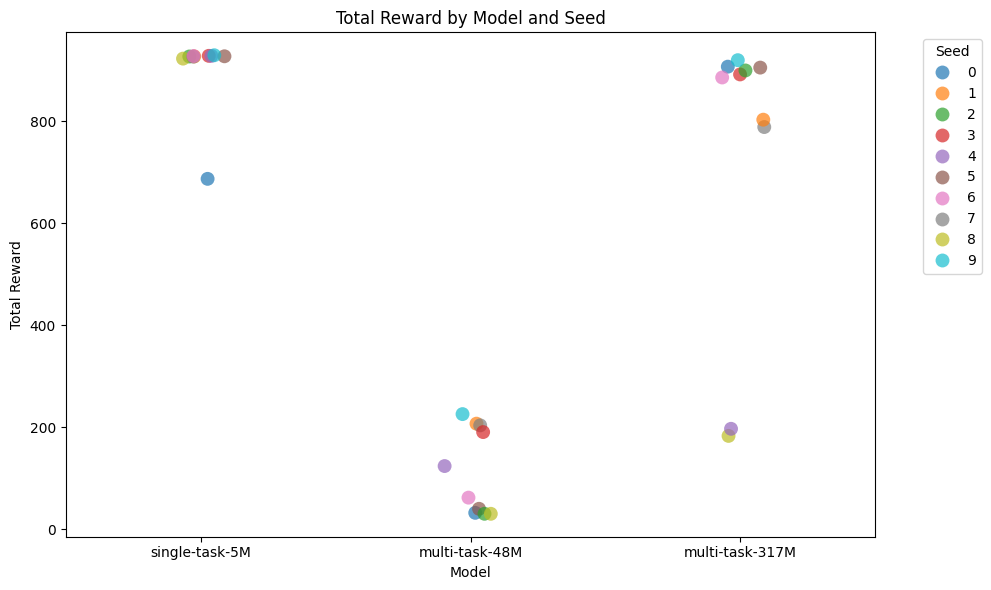

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

checkpoint_map = {
    'ckpts/cheetah-run-3.pt': 'single-task-5M',
    'ckpts/mt30-48M.pt': 'multi-task-48M',
    'ckpts/mt30-317M.pt': 'multi-task-317M',
}

# Create a single plot
fig, ax = plt.subplots(figsize=(10, 6))

# Set checkpoint order
checkpoint_order = list(checkpoint_map.keys())

# Create stripplot with checkpoints on x-axis, total_reward on y-axis, colored by seed
sns.stripplot(data=df,
              x='checkpoint',
              y='total_reward',
              hue='seed',
              ax=ax,
              alpha=0.7,
              jitter=True,
              size=10,
              order=checkpoint_order,
              palette='tab10')

# Set labels with mapped checkpoint names
ax.set_xlabel('Model')
ax.set_ylabel('Total Reward')
ax.set_title('Total Reward by Model and Seed')
ax.set_xticklabels([checkpoint_map[ckpt] for ckpt in checkpoint_order])
ax.legend(title='Seed', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [10]:
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
import matplotlib.pyplot as plt
import numpy as np


def correlation_matrix(z):
    sim = np.corrcoef(z.T)

    # Perform hierarchical clustering for stable
    link = linkage(sim, method='ward')
    order = leaves_list(link)
    sim_reordered = sim[order][:, order]

    return sim, sim_reordered

In [12]:
df_single_task = df[df['checkpoint'] == 'ckpts/cheetah-run-3.pt']
df_multi_task_big = df[df['checkpoint'] == 'ckpts/mt30-317M.pt']
df_multi_task_small = df[df['checkpoint'] == 'ckpts/mt30-48M.pt']

obs_single_task = np.concatenate(df_single_task['observations'].tolist())
z_single_task = np.concatenate(df_single_task['latent_states'].tolist())

obs_multi_task_big = np.concatenate(df_multi_task_big['observations'].tolist())
z_multi_task_big = np.concatenate(df_multi_task_big['latent_states'].tolist())

obs_multi_task_small = np.concatenate(
    df_multi_task_small['observations'].tolist())
z_multi_task_small = np.concatenate(
    df_multi_task_small['latent_states'].tolist())


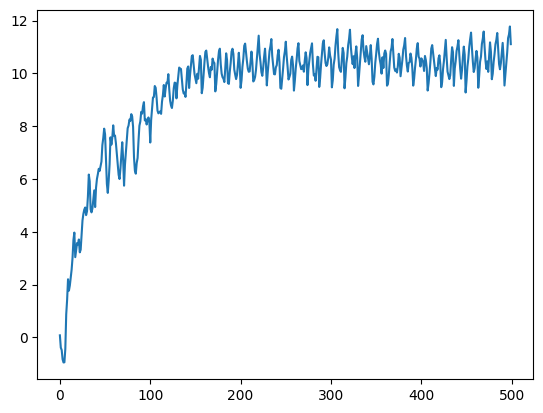

In [29]:
plt.plot(obs_multi_task_big[:500, 8])
plt.show()

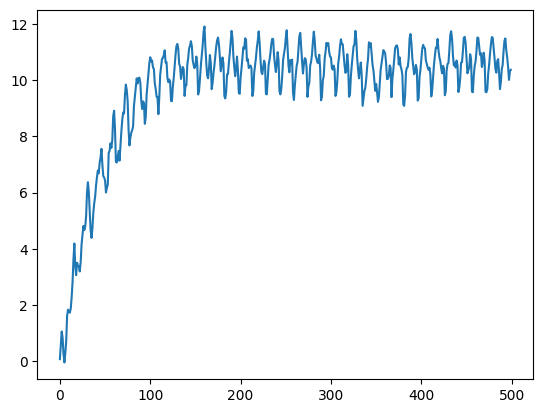

In [27]:
position = obs_single_task[:, :8]  # qpos[1:]
velocity = obs_single_task[:, 8:]  # qvel[:]  -> 9 dims
vel_torso = velocity[:, 0][:, None]
plt.plot(vel_torso[:500])
plt.show()

In [15]:
sim_single_task, sim_single_task_clustered = correlation_matrix(z_single_task)
sim_multi_task_big, sim_multi_task_big_clustered = correlation_matrix(
    z_multi_task_big)
sim_multi_task_small, sim_multi_task_small_clustered = correlation_matrix(
    z_multi_task_small)


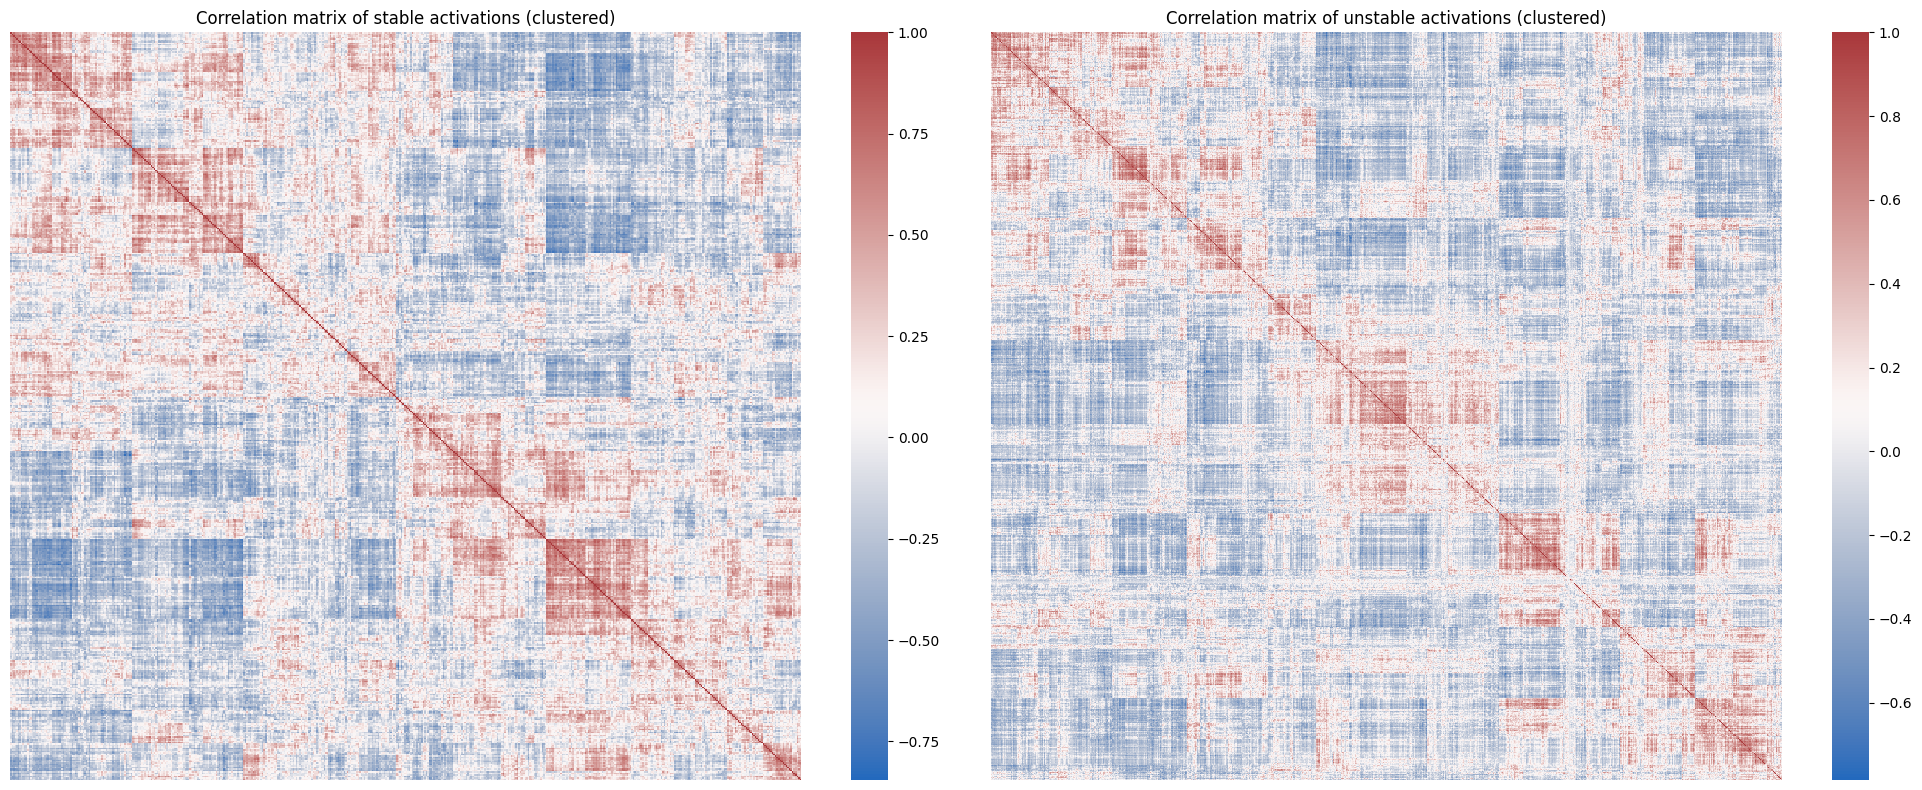

In [16]:
# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(sim_single_task_clustered,
            vmin=sim_single_task.min(),
            vmax=sim_single_task.max(),
            cmap='vlag',
            ax=axes[0],
            xticklabels=False,
            yticklabels=False)
axes[0].set_title("Correlation matrix of stable activations (clustered)")

sns.heatmap(sim_multi_task_big_clustered,
            vmin=sim_multi_task_big.min(),
            vmax=sim_multi_task_big.max(),
            cmap='vlag',
            ax=axes[1],
            xticklabels=False,
            yticklabels=False)
axes[1].set_title("Correlation matrix of unstable activations (clustered)")

plt.tight_layout()
plt.show()

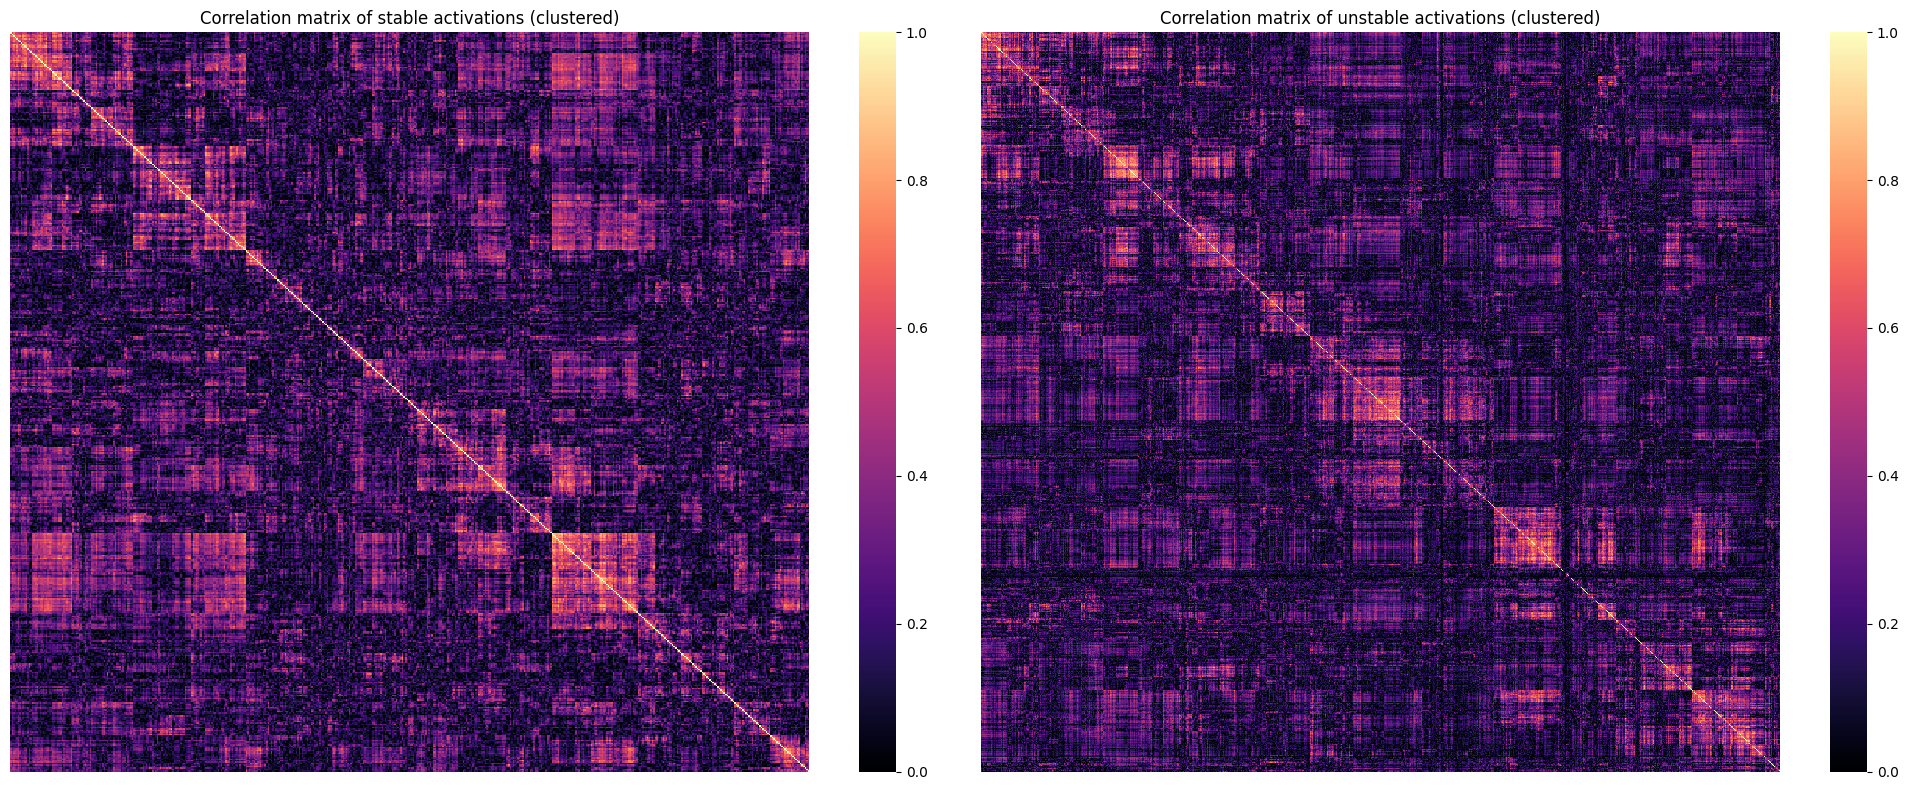

In [17]:
# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(np.abs(sim_single_task_clustered),
            vmin=0,
            vmax=np.abs(sim_single_task).max(),
            cmap='magma',
            ax=axes[0],
            xticklabels=False,
            yticklabels=False)
axes[0].set_title("Correlation matrix of stable activations (clustered)")

sns.heatmap(np.abs(sim_multi_task_big_clustered),
            vmin=0,
            vmax=np.abs(sim_multi_task_big).max(),
            cmap='magma',
            ax=axes[1],
            xticklabels=False,
            yticklabels=False)
axes[1].set_title("Correlation matrix of unstable activations (clustered)")

plt.tight_layout()
plt.show()

In [ ]:
def process_model_data(df_model, threshold=6):
    """
    Process observations and latent states for a given model dataframe.
    
    Args:
        df_model: DataFrame containing observations and latent_states for a specific model
        threshold: Threshold for determining stable states based on cos_pole_angle
    
    Returns:
        Dictionary containing:
            - obs: concatenated observations
            - z: concatenated latent states
            - z_stable: latent states for stable configurations
            - z_unstable: latent states for unstable configurations
            - stable_mask: boolean mask for stable states
            - unstable_mask: boolean mask for unstable states
    """
    obs = np.concatenate(df_model['observations'].tolist())
    z = np.concatenate(df_model['latent_states'].tolist())

    velocity = obs[:, 8]
    fast_mask = (velocity >= threshold)
    slow_mask = ~fast_mask

    z_fast = z[fast_mask]
    z_slow = z[slow_mask]

    return {
        'obs': obs,
        'z': z,
        'z_fast': z_fast,
        'z_slow': z_slow,
        'fast_mask': fast_mask,
        'slow_mask': slow_mask
    }


# Process data for each model
single_task_data = process_model_data(df_single_task)
multi_task_big_data = process_model_data(df_multi_task_big)
multi_task_small_data = process_model_data(df_multi_task_small)

# Extract for convenience
obs_single_task = single_task_data['obs']
obs_multi_task_big = multi_task_big_data['obs']
obs_multi_task_small = multi_task_small_data['obs']

z_single_task = single_task_data['z']
z_multi_task_big = multi_task_big_data['z']
z_multi_task_small = multi_task_small_data['z']

z_single_task_stable = single_task_data['z_stable']
z_single_task_unstable = single_task_data['z_unstable']
z_multi_task_big_stable = multi_task_big_data['z_stable']
z_multi_task_big_unstable = multi_task_big_data['z_unstable']
z_multi_task_small_stable = multi_task_small_data['z_stable']
z_multi_task_small_unstable = multi_task_small_data['z_unstable']
